### Q-learning model

In [18]:
# Imports
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
import random

# Eviroment aanmaken
env = gym.make("Taxi-v3")
eval_env = gym.make("Taxi-v3", render_mode="human")

# Q-table aanmaken
q_table = np.zeros((env.observation_space.n,
                    env.action_space.n))

# zeros: Alle waarden in de Q-table worden geïnitialiseerd op 0
# observation_space.n: Het aantal mogelijke staten in de omgeving (500)
# action_space.n: Het aantal mogelijke acties die de agent kan nemen (6)

# Hyperparameters instellen
alpha = [0.1, 0.5, 0.9]  # Leerpercentage: Hoe snel de agent leert van nieuwe ervaringen
gamma = [0.6, 0.8, 0.9]  # Kortingsfactor: Hoeveel waarde hecht de agent aan toekomstige beloningen
epsilon = [0.1, 0.05, 0.01]  # Exploratiepercentage: Kans dat de agent een willekeurige actie kiest in plaats van de actie met de hoogste Q-waarde
epsilon_decay = [0.99, 0, 0.98]  # Decay factor voor epsilon: Hoeveel epsilon afneemt na elke episode
epsilon_min = [0.01, 0.02, 0.03]  # Minimum waarde voor epsilon: De agent zal altijd minstens deze kans hebben om te exploreren
episodes = 1000  # Aantal trainingsepisodes: Hoeveel keer de agent de omgeving zal verkennen en leren

random.seed(42)
np.random.seed(42)

In [19]:
import itertools

# Alle combinaties van hyperparameters
hyperparams = list(itertools.product(alpha, gamma, epsilon, epsilon_decay, epsilon_min))

results = []

for idx, (a, g, e, e_decay, e_min) in enumerate(hyperparams):
    q_table = np.zeros((env.observation_space.n, env.action_space.n))
    rewards_per_episode = []
    episode_steps = []
    successes = []
    illegal_actions_per_episode = []
    eps = e
    for episode in range(episodes):
        state, info = env.reset(seed=42)
        done = False
        total_reward = 0
        steps = 0
        illegal_actions = 0
        success = 0
        max_steps = 200
        while not done and steps < max_steps:
            if np.random.random() < eps:
                action = env.action_space.sample()
            else:
                action = np.argmax(q_table[state])
            next_state, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated
            old_value = q_table[state, action]
            next_max = np.max(q_table[next_state])
            q_table[state, action] = old_value + a * (reward + g * next_max - old_value)
            state = next_state
            total_reward += reward
            steps += 1
            if reward == -10:
                illegal_actions += 1
            if reward == 20:
                success = 1
        episode_steps.append(steps)
        successes.append(success)
        illegal_actions_per_episode.append(illegal_actions)
        rewards_per_episode.append(total_reward)
        eps = max(e_min, eps * e_decay)
    results.append({
        'alpha': a,
        'gamma': g,
        'epsilon': e,
        'epsilon_decay': e_decay,
        'epsilon_min': e_min,
        'rewards_per_episode': rewards_per_episode,
        'successes': successes,
        'illegal_actions_per_episode': illegal_actions_per_episode,
        'episode_steps': episode_steps,
        'q_table': q_table
    })
print(f"Klaar met {len(hyperparams)} combinaties van hyperparameters.")

Klaar met 243 combinaties van hyperparameters.


In [20]:
average_rewards = []

window_size = 100

for i in range(len(rewards_per_episode)):
    start = max(0, i - window_size)
    average = np.mean(rewards_per_episode[start:i+1])
    average_rewards.append(average)

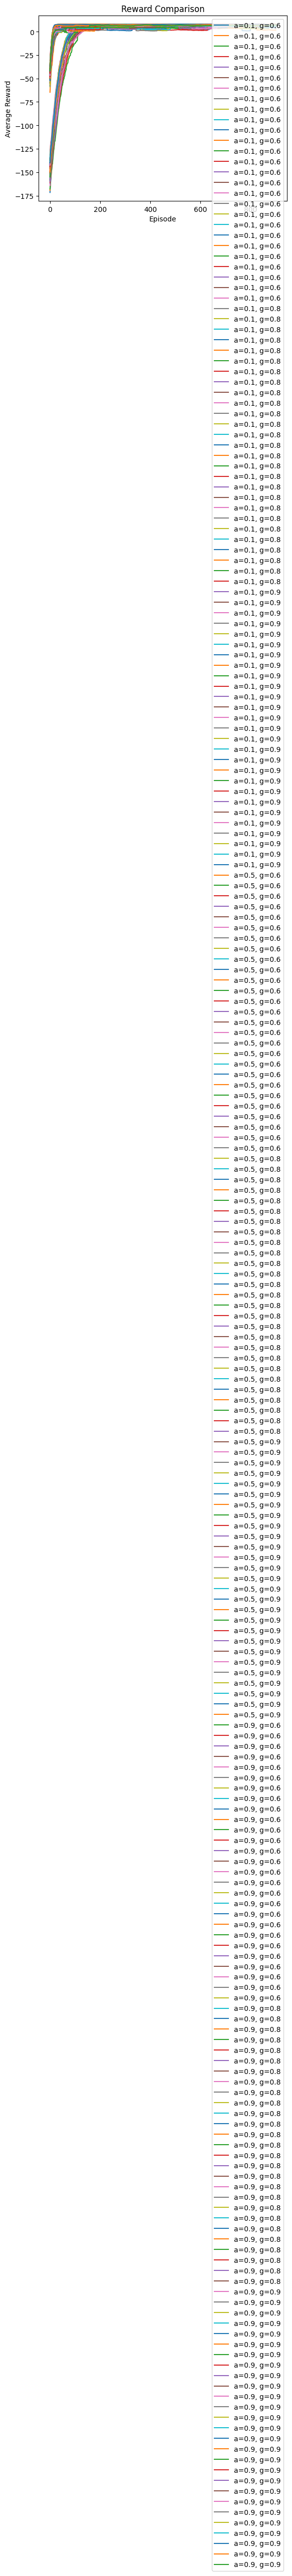

In [21]:
window = 100

for result in results:

    rewards = result['rewards_per_episode']

    moving_avg = np.convolve(
        rewards,
        np.ones(window)/window,
        mode='valid'
    )

    label = f"a={result['alpha']}, g={result['gamma']}"

    plt.plot(moving_avg, label=label)

plt.xlabel("Episode")
plt.ylabel("Average Reward")
plt.title("Reward Comparison")

plt.legend()

plt.show()

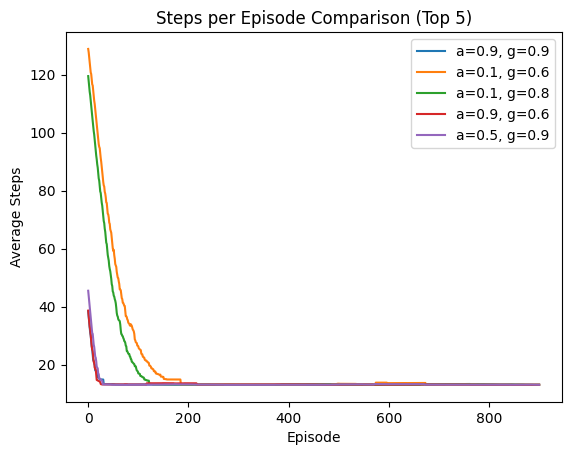

In [22]:
window = 100

# Selecteer de 5 beste runs op basis van gemiddelde beloning
sorted_results = sorted(results, key=lambda r: np.mean(r['rewards_per_episode'][-window:]), reverse=True)
best_results = sorted_results[:5]

for result in best_results:
    steps = result['episode_steps']
    avg_steps = np.convolve(
        steps,
        np.ones(window)/window,
        mode='valid'
    )
    label = f"a={result['alpha']}, g={result['gamma']}"
    plt.plot(avg_steps, label=label)

plt.xlabel("Episode")
plt.ylabel("Average Steps")
plt.title("Steps per Episode Comparison (Top 5)")
plt.legend()
plt.show()


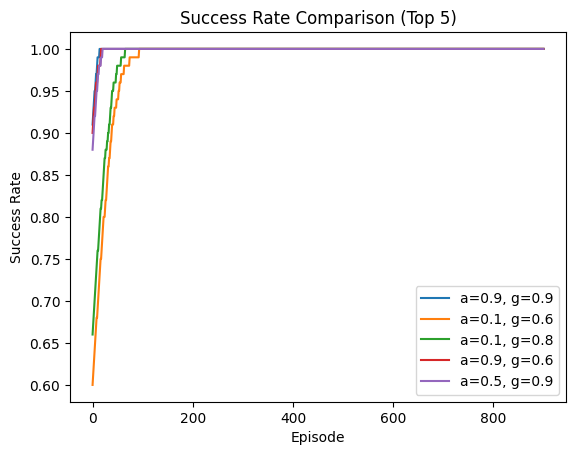

In [23]:
window = 100

# Selecteer de 5 beste runs op basis van gemiddelde beloning
sorted_results = sorted(results, key=lambda r: np.mean(r['rewards_per_episode'][-window:]), reverse=True)
best_results = sorted_results[:5]

for result in best_results:
    successes = result['successes']
    success_rate = np.convolve(
        successes,
        np.ones(window)/window,
        mode='valid'
    )
    label = f"a={result['alpha']}, g={result['gamma']}"
    plt.plot(success_rate, label=label)

plt.xlabel("Episode")
plt.ylabel("Success Rate")
plt.title("Success Rate Comparison (Top 5)")
plt.legend()
plt.show()


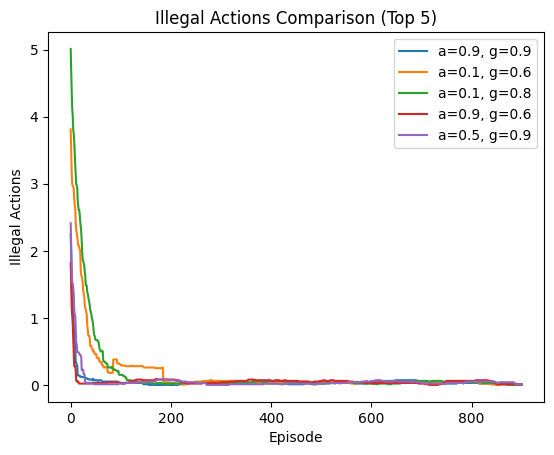

In [24]:
window = 100

# Selecteer de 5 beste runs op basis van gemiddelde beloning
sorted_results = sorted(results, key=lambda r: np.mean(r['rewards_per_episode'][-window:]), reverse=True)
best_results = sorted_results[:5]

for result in best_results:
    illegal = result['illegal_actions_per_episode']
    avg_illegal = np.convolve(
        illegal,
        np.ones(window)/window,
        mode='valid'
    )
    label = f"a={result['alpha']}, g={result['gamma']}"
    plt.plot(avg_illegal, label=label)

plt.xlabel("Episode")
plt.ylabel("Illegal Actions")
plt.title("Illegal Actions Comparison (Top 5)")
plt.legend()
plt.show()


In [25]:
results.append({

    'alpha': alpha,
    'gamma': gamma,
    'epsilon': eps,

    'rewards_per_episode': rewards_per_episode,
    'episode_steps': episode_steps,
    'successes': successes,
    'illegal_actions_per_episode': illegal_actions_per_episode,

    'q_table': q_table
})

In [26]:
best_result = max(
    results,
    key=lambda x: np.mean(x['rewards_per_episode'][-100:])
)

print(best_result['alpha'])
print(best_result['gamma'])
print(best_result['epsilon'])
best_q_table = best_result['q_table']
action = np.argmax(best_q_table[state])

0.9
0.9
0.05


In [27]:
state, info = env.reset()
done = False

while not done:

    action = np.argmax(q_table[state])

    state, reward, terminated, truncated, info = env.step(action)

    done = terminated or truncated

    env.render()

c:\Users\j0rd4\AppData\Local\Programs\Python\Python311\Lib\site-packages\gymnasium\envs\toy_text\taxi.py:443: UserWarning: WARN: You are calling render method without specifying any render mode. You can specify the render_mode at initialization, e.g. gym.make("Taxi-v3", render_mode="rgb_array")
  gym.logger.warn(
